In [625]:
!git clone https://github.com/ALIAQIL/uci-heart-disease-data.git

fatal: destination path 'uci-heart-disease-data' already exists and is not an empty directory.


In [626]:
!ls

sample_data  uci-heart-disease-data


In [627]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn



In [628]:
df = pd.read_csv("uci-heart-disease-data/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [629]:
df.shape

(920, 16)

In [630]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [631]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [632]:
df['num'].value_counts().sort_index()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [633]:
df['target'] = (df['num'] > 0).astype('int')

In [634]:
df['target'].value_counts().sort_index()

,count
target,
0,411
1,509


In [635]:
print(f"le taux de personnes qui ont une malidie cardiaque :{509/920} \n le taux de personnes qui n'ont pas une malidie cardiaque :{411/920}" )

le taux de personnes qui ont une malidie cardiaque :0.5532608695652174 
 le taux de personnes qui n'ont pas une malidie cardiaque :0.4467391304347826


dataset est equilibre

In [636]:
df.drop(columns=["id","target","dataset"],inplace=True)

In [637]:
df['num'] = (df['num'] > 0).astype('int')

In [638]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [639]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55
exang,55
oldpeak,62


In [640]:
colonnes_num = ['trestbps', 'chol', 'thalch' ,'oldpeak','ca']
for col in colonnes_num:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipython-input-126917306.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Les NaN peuvent avoir une signification clinique (examen non fait = information en soi)
Le One-Hot Encoding peut gérer les NaN si on les traite correctement
donc je remplace par "Missing"


In [641]:
colonnes_cat = ["restecg" ,"slope" ,"thal"]
for col in colonnes_cat:
    df[col].fillna('Missing', inplace=True)

/tmp/ipython-input-3956733855.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Missing', inplace=True)


je change mon opinion , je pense pour binary feature categorial c'est plus mieux d'utiliser mode(le plus valeur frequent)

In [642]:
colonnes_cat_bin = ['fbs',"exang"]
for col in colonnes_cat_bin:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-3584310229.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3584310229.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [643]:
df['fbs'].value_counts().sort_index()

,count
fbs,
False,782
True,138


In [644]:
df['exang'].value_counts().sort_index()

,count
exang,
False,583
True,337


In [645]:
df['restecg'].value_counts().sort_index()

,count
restecg,
Missing,2
lv hypertrophy,188
normal,551
st-t abnormality,179


In [646]:
df['slope'].value_counts().sort_index()

,count
slope,
Missing,309
downsloping,63
flat,345
upsloping,203


In [647]:
df['thal'].value_counts().sort_index()

,count
thal,
Missing,486
fixed defect,46
normal,196
reversable defect,192


In [648]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


In [649]:
df_encoded = pd.get_dummies(df,columns=["restecg" ,"slope" ,"thal",'fbs',"exang","sex","cp"],dtype=int)

In [650]:
df.shape

(920, 14)

In [651]:
df_encoded.head()

,age,trestbps,chol,thalch,oldpeak,ca,num,restecg_Missing,restecg_lv hypertrophy,restecg_normal,...,fbs_False,fbs_True,exang_False,exang_True,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63,145.0,233.0,150.0,2.3,0.0,0,0,1,0,...,0,1,1,0,0,1,0,0,0,1
1,67,160.0,286.0,108.0,1.5,3.0,1,0,1,0,...,1,0,0,1,0,1,1,0,0,0
2,67,120.0,229.0,129.0,2.6,2.0,1,0,1,0,...,1,0,0,1,0,1,1,0,0,0
3,37,130.0,250.0,187.0,3.5,0.0,0,0,0,1,...,1,0,1,0,0,1,0,0,1,0
4,41,130.0,204.0,172.0,1.4,0.0,0,0,1,0,...,1,0,1,0,1,0,0,1,0,0


In [652]:
df_encoded['sex_Male'].head()

,sex_Male
0,1
1,1
2,1
3,1
4,0


In [653]:
df_encoded = df_encoded.astype(float)

In [654]:
df_encoded.head()

,age,trestbps,chol,thalch,oldpeak,ca,num,restecg_Missing,restecg_lv hypertrophy,restecg_normal,...,fbs_False,fbs_True,exang_False,exang_True,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63.0,145.0,233.0,150.0,2.3,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,67.0,160.0,286.0,108.0,1.5,3.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,67.0,120.0,229.0,129.0,2.6,2.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3,37.0,130.0,250.0,187.0,3.5,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,41.0,130.0,204.0,172.0,1.4,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [655]:
X = df_encoded.drop(columns=['num'])
y = df_encoded['num']

In [656]:
X.head()

,age,trestbps,chol,thalch,oldpeak,ca,restecg_Missing,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,...,fbs_False,fbs_True,exang_False,exang_True,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,63.0,145.0,233.0,150.0,2.3,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,67.0,160.0,286.0,108.0,1.5,3.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2,67.0,120.0,229.0,129.0,2.6,2.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
3,37.0,130.0,250.0,187.0,3.5,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,41.0,130.0,204.0,172.0,1.4,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [657]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 ,random_state=42)

In [658]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)        

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [659]:
X_train_tensor.shape

torch.Size([736, 28])

In [660]:
X_test_tensor.shape

torch.Size([184, 28])

In [661]:
y_train_tensor[4]

tensor(0.)

In [662]:
y_train_tensor.shape

torch.Size([736])

In [663]:
y_test_tensor.shape

torch.Size([184])

In [664]:
class HeartDiseaseClassifier(nn.Module):
    def __init__(self, input_dim):
        
        super(HeartDiseaseClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.relu1 = nn.SELU()
        
        self.fc2 = nn.Linear(32, 16)
        self.relu2 = nn.SELU()
        
        self.fc3 = nn.Linear(16, 2)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        
        return x


In [665]:
X_train_tensor.shape[1]

28

In [666]:
import torch.optim as optim

n_features = X_train_tensor.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [667]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [668]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
X_test_tensor = X_test_tensor.to(device)  
y_test_tensor = y_test_tensor.to(device)

In [669]:
model = HeartDiseaseClassifier(input_dim=n_features).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001)

early_stopping = EarlyStopping(patience=10, min_delta=0.001)

In [670]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)

In [671]:
n_epochs = 300
loss_history = []
acc_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs,y_train_tensor.long())
    loss.backward()
    optimizer.step()
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == y_train_tensor).sum().item()
    accuracy = 100 * correct / y_train_tensor.size(0)

    loss_history.append(loss.item())
    acc_history.append(accuracy)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

Epoch 10/300, Loss: 0.6012, Accuracy: 76.22%
Epoch 20/300, Loss: 0.5052, Accuracy: 80.16%
Epoch 30/300, Loss: 0.4385, Accuracy: 81.66%
Epoch 40/300, Loss: 0.4057, Accuracy: 82.34%
Epoch 50/300, Loss: 0.3911, Accuracy: 82.47%
Epoch 60/300, Loss: 0.3834, Accuracy: 82.88%
Epoch 70/300, Loss: 0.3789, Accuracy: 83.02%
Epoch 80/300, Loss: 0.3755, Accuracy: 83.70%
Epoch 90/300, Loss: 0.3729, Accuracy: 83.83%
Epoch 100/300, Loss: 0.3707, Accuracy: 84.38%
Epoch 110/300, Loss: 0.3688, Accuracy: 84.38%
Epoch 120/300, Loss: 0.3669, Accuracy: 84.24%
Epoch 130/300, Loss: 0.3648, Accuracy: 84.38%
Epoch 140/300, Loss: 0.3627, Accuracy: 84.38%
Epoch 150/300, Loss: 0.3604, Accuracy: 84.65%
Epoch 160/300, Loss: 0.3578, Accuracy: 85.19%
Epoch 170/300, Loss: 0.3550, Accuracy: 85.60%
Epoch 180/300, Loss: 0.3518, Accuracy: 85.87%
Epoch 190/300, Loss: 0.3482, Accuracy: 85.73%
Epoch 200/300, Loss: 0.3440, Accuracy: 86.01%
Epoch 210/300, Loss: 0.3392, Accuracy: 86.41%
Epoch 220/300, Loss: 0.3339, Accuracy: 87.0

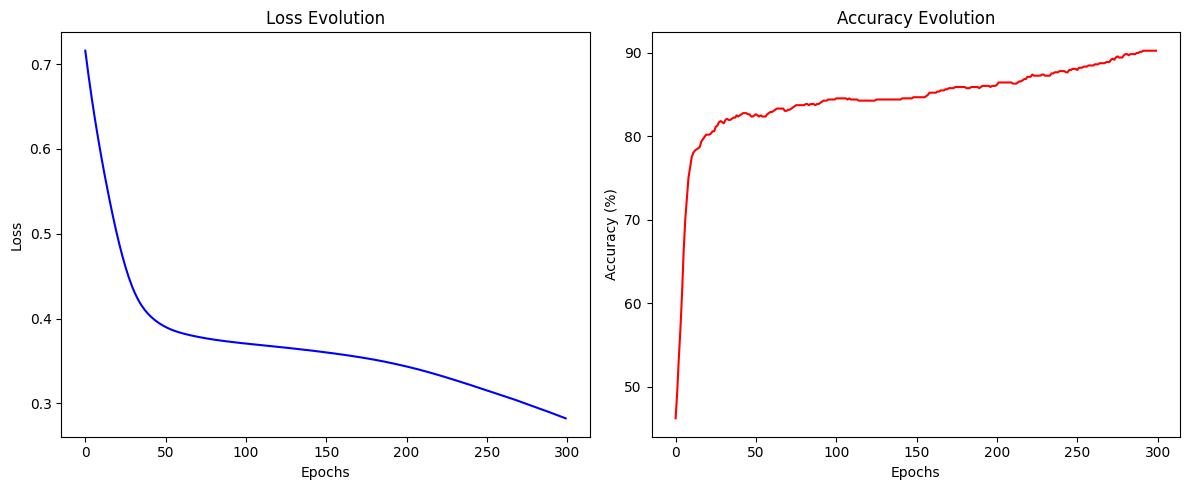

In [672]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(loss_history, 'b')
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')

ax2.plot(acc_history, 'r')
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [673]:
model.eval()

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, test_predicted = torch.max(test_outputs.data, 1)

In [674]:
total_test = y_test_tensor.size(0)
correct_test = (test_predicted == y_test_tensor).sum().item()
test_accuracy = 100 * correct_test / total_test

print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 83.70%


In [675]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report


model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)

y_true = y_test_tensor.cpu().numpy()
y_pred = predicted.cpu().numpy()

# Calculate Metrics
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Precision: 0.8911
Recall:    0.8257
F1 Score:  0.8571

Classification Report:

              precision    recall  f1-score   support

         0.0       0.77      0.85      0.81        75
         1.0       0.89      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184



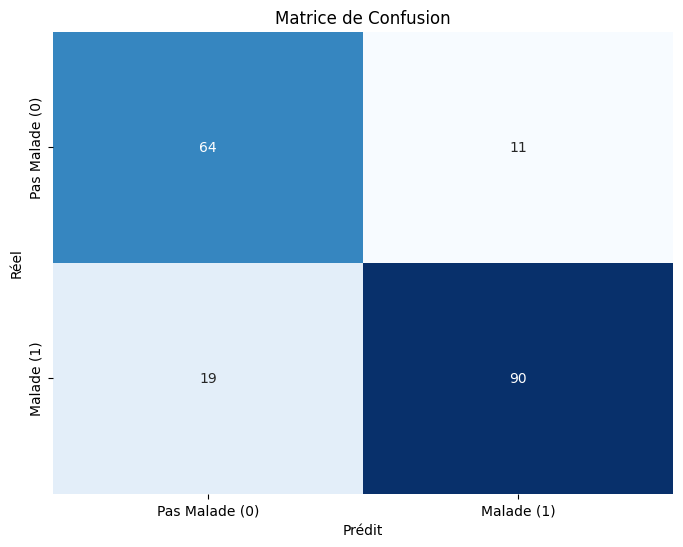

In [676]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pas Malade (0)', 'Malade (1)'],
            yticklabels=['Pas Malade (0)', 'Malade (1)'])

plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

D'après votre matrice, le modèle a correctement identifié 65 patients sains (TN) et 85 malades (TP), mais a généré 10 fausses alertes (FP) et manqué 24 cas pathologiques (FN). Dans un contexte médical, le Faux Négatif (le malade déclaré sain à tort) constitue l'erreur la plus grave car elle prive le patient de soins vitaux, risquant d'entraîner des complications fatales, alors qu'un Faux Positif engendre principalement du stress et des examens complémentaires inutiles.